# Numerical validation of the social-cue capture fraction

Checks every equation in `pc_social_cue.tex` against **direct microscopic
Monte Carlo**: place a tagged agent, let it diffuse, place the target where the
agent was, sample a uniform heading, apply the simulator's own capture rule,
count. No MFPT, no `A`, no `b`, no fitted constant — this is exact geometry,
so any disagreement is an error in the algebra, not physics.

Equations are referenced by their LaTeX `\label`, not by number. Numbers shift
every time the document is edited, and they already have: an earlier version of
this notebook cited "Eq. (5)" for the convolution formula, which is in fact
Eq. 7. Current numbers below are parenthetical and may go stale; the labels
will not.

| # | claim | label | (no. at time of writing) |
|---|-------|-------|--------------------------|
| A | the convolution formula itself | `eq:pcsocial` | (7) |
| B | `s -> 0` recovers direct vision | `eq:pcdirect` | (1) |
| C | wide cone immune to the blur, `pc -> alpha/pi` | `eq:widecone` | (11) |
| D | narrow cone suppressed by `erf(alpha/beta/sqrt2)` | `eq:narrowcone` | (13) |
| E | the two competing corrections | `eq:pcexact` | (9) |
| F | the re-aiming variant | caveat section | -- |

Supporting definitions: `eq:sigma` (3) for `sigma = sqrt(2Ds)`, `eq:beta` (5)
for the angular blur `beta = sigma/VR`.

## RESULT OF RUNNING THIS: `eq:pcsocial` IS ONLY LEADING ORDER,
## AND `eq:widecone` IS WRONG

The MC falsifies the wide-cone immunity claim: pc RISES from 0.0533 to 0.0624
(+16%) by s=5, then falls. Two effects were omitted from the derivation, both
O(sigma/VR), and they compete:

1. **Forward condition.** The target can drift BEHIND the observer. The
   derivation never imposed C_x > 0. Measured loss matches P(Delta_x > VR)
   to three digits: 9.1% vs 9.0% at s=10, 25.1% vs 25.1% at s=40. LOWERS pc.
2. **Pile-up.** The claim "uniform phi implies uniform target bearing, so
   convolution preserves area" is false. The convolution happens in the
   PERPENDICULAR COORDINATE y = VR sin(phi), whose density
   1/(2 pi sqrt(VR^2 - y^2)) is U-SHAPED with its minimum at y = 0. Smoothing
   fills in a minimum, so blur RAISES pc.

The exact result (`eq:pcexact`), verified below to within 0.4% over the whole
range, is

    pc = (1/2pi) int_{-theta/2}^{theta/2}
           [Phi((VR sin phi + r)/sigma) - Phi((VR sin phi - r)/sigma)]
           * Phi(VR cos phi / sigma) dphi

with the bracket the lateral hit probability and the last factor the
probability that the target is still in front. `eq:pcsocial` is what you get by
setting sin phi -> phi and Phi(VR cos phi/sigma) -> 1, i.e. leading order in
sigma/VR. It is fine for sigma << VR and degrades from there.

**One thing the MC tests that the derivation glossed over.** The formula
linearises the perpendicular offset as `VR*phi + D_perp`, but the exact
geometry is `VR*sin(phi) - D_perp`. The MC uses the exact form, so Check A is
also a test of that small-angle step.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
from scipy.integrate import quad
from scipy.special import erf

# ---------------- parameters ----------------
r   = 0.5        # target radius
VR  = 3.0        # detection range (observer -> tagged agent)
D   = 0.25       # diffusion constant of the tagged agent  (= d/4, d=1)
N   = 2_000_000  # MC samples

alpha = np.arcsin(min(r/VR, 1.0))
sigma_of = lambda s: np.sqrt(2*D*s)      # per-component drift, `eq:sigma`
beta_of  = lambda s: sigma_of(s)/VR      # angular blur, `eq:beta`

print(f"r={r}  VR={VR}  D={D}   ->  alpha = arcsin(r/VR) = {alpha:.4f}")
print(f"direct-vision wide-cone value alpha/pi = {alpha/np.pi:.5f}")

r=0.5  VR=3.0  D=0.25   ->  alpha = arcsin(r/VR) = 0.1674
direct-vision wide-cone value alpha/pi = 0.05330


## Theory: the equations under test

In [ ]:
def pc_convolution(theta, s, alpha=alpha, VR=VR):
    """`eq:pcsocial`: top hat of half width alpha convolved with a Gaussian of
    width beta, truncated to the cone. LEADING ORDER in sigma/VR only."""
    b = beta_of(s)
    if b < 1e-9:                                   # delta limit
        return min(theta, 2*alpha)/(2*np.pi)
    f = lambda p: norm.cdf((alpha-p)/b) - norm.cdf((-alpha-p)/b)
    return quad(f, -theta/2, theta/2, limit=400)[0]/(2*np.pi)


def pc_exact(theta, s, r=r, VR=VR):
    """EXACT capture fraction: no small-angle step, forward condition included.
    Verified against MC to <0.4% for s in [0, 40], theta in [0.05, 2pi]."""
    sig = sigma_of(s)
    if sig < 1e-9:
        return min(theta, 2*np.arcsin(min(r/VR, 1.0)))/(2*np.pi)
    def f(p):
        lateral = (norm.cdf((VR*np.sin(p) + r)/sig)
                   - norm.cdf((VR*np.sin(p) - r)/sig))
        forward = norm.cdf(VR*np.cos(p)/sig)
        return lateral*forward
    return quad(f, -theta/2, theta/2, limit=400)[0]/(2*np.pi)


def pc_direct(theta, alpha=alpha):
    """`eq:pcdirect`: the s -> 0 limit, direct vision."""
    return min(theta, 2*alpha)/(2*np.pi)


def pc_wide(alpha=alpha):
    """`eq:widecone`: claimed wide-cone limit, independent of s. FALSIFIED
    beyond leading order -- see Check C."""
    return alpha/np.pi


def pc_narrow(theta, s, alpha=alpha):
    """`eq:narrowcone`: narrow-cone limit."""
    b = beta_of(s)
    return (theta/(2*np.pi)) * erf(alpha/(b*np.sqrt(2)))


def pc_aim(theta, s, r=r):
    """Caveat section: if the searcher could re-aim at the tagged agent.
    Note VR has cancelled out entirely."""
    return (theta/(2*np.pi)) * erf(r/(sigma_of(s)*np.sqrt(2)))

## Ground truth: direct microscopic Monte Carlo

Observer at the origin, heading along `+x` without loss of generality (the
whole problem is isotropic). Tagged agent `j` at distance `VR`, bearing `phi`
uniform. Target `C = j - Delta`, with `Delta` isotropic Gaussian of
per-component width `sigma`. Capture iff `j` is inside the cone **and** the
forward ray along `+x` passes within `r` of `C`.

**Variance reduction:** rather than sampling `phi` over the full circle and
throwing most of it away, sample `phi` uniformly *inside the cone* and
multiply by `theta/(2*pi)`. This is exact, and makes narrow cones (where `pc`
is tiny) cheap to measure.

In [ ]:
def measure_pc(theta, s, n=N, seed=0, max_dash=None, reaim=False):
    """Direct MC of the social capture fraction. Returns (pc, sem)."""
    rng = np.random.default_rng(seed)
    sig = sigma_of(s)

    phi = rng.uniform(-theta/2, theta/2, n)          # bearing of the TAGGED AGENT
    j = np.column_stack([VR*np.cos(phi), VR*np.sin(phi)])
    delta = rng.normal(0.0, sig, size=(n, 2))        # drift during the tag age
    C = j - delta                                    # where the TARGET actually is

    if reaim:                                        # steer straight at j
        h = j/np.linalg.norm(j, axis=1, keepdims=True)
        along = C[:, 0]*h[:, 0] + C[:, 1]*h[:, 1]
        perp = np.abs(h[:, 0]*C[:, 1] - h[:, 1]*C[:, 0])
    else:                                            # commit to the heading (+x)
        along = C[:, 0]
        perp = np.abs(C[:, 1])

    hit = (perp <= r) & (along > 0)
    if max_dash is not None:                         # optional finite dash length
        entry = along - np.sqrt(np.clip(r**2 - perp**2, 0, None))
        hit &= (entry <= max_dash)

    p_in_cone = hit.mean()                           # conditional on being in cone
    pc = p_in_cone * theta/(2*np.pi)                 # times P(in cone)
    sem = np.sqrt(p_in_cone*(1-p_in_cone)/n) * theta/(2*np.pi)
    return pc, sem

## CHECK A — `eq:pcsocial` itself

Sweep cone angle and tag age. `n sigma` is the discrepancy in units of the MC
error bar; anything beyond ~3 is a real disagreement.

In [ ]:
print("CHECK A - eq:pcsocial vs direct MC\n")
print(f"{'theta':>7} {'s':>6} {'sig/VR':>7} {'MC':>10} {'+-':>9} "
      f"{'conv':>10} {'r_c':>7} {'EXACT':>10} {'rX':>7}")
for theta in [0.05, 0.5, 1.5, 2*np.pi]:
    for s in [0.0, 1.0, 4.0, 10.0, 40.0]:
        mc, sem = measure_pc(theta, s, seed=1)
        t5, tx = pc_convolution(theta, s), pc_exact(theta, s)
        print(f"{theta:7.3f} {s:6.1f} {sigma_of(s)/VR:7.3f} {mc:10.6f} {sem:9.6f} "
              f"{t5:10.6f} {mc/t5:7.4f} {tx:10.6f} {mc/tx:7.4f}")
print("\nr_c = MC/eq:pcsocial drifts from 1 as sigma/VR grows (leading order only)")
print("rX = MC/exact stays at 1 throughout")

CHECK A - eq:pcsocial vs direct MC

  theta      s  sig/VR         MC        +-       conv     r_c      EXACT      rX
  0.050    0.0   0.000   0.007958  0.000000   0.007958  1.0000   0.007958  1.0000
  0.050    1.0   0.236   0.004134  0.000003   0.004152  0.9956   0.004135  0.9996
  0.050    4.0   0.471   0.002159  0.000003   0.002208  0.9778   0.002161  0.9991
  0.050   10.0   0.745   0.001281  0.000002   0.001414  0.9059   0.001281  1.0000
  0.050   40.0   1.491   0.000531  0.000001   0.000712  0.7468   0.000530  1.0020
  0.500    0.0   0.000   0.053297  0.000026   0.053300  0.9999   0.053300  0.9999
  0.500    1.0   0.236   0.035719  0.000028   0.035842  0.9966   0.035751  0.9991
  0.500    4.0   0.471   0.020675  0.000025   0.021134  0.9783   0.020674  1.0000
  0.500   10.0   0.745   0.012541  0.000021   0.013889  0.9030   0.012554  0.9990
  0.500   40.0   1.491   0.005258  0.000014   0.007084  0.7422   0.005265  0.9987
  1.500    0.0   0.000   0.053274  0.000070   0.053300  0.9995

## CHECK B — the `s -> 0` limit recovers direct vision

In [ ]:
print("\nCHECK B - s -> 0 recovers min(theta, 2 alpha)/2pi\n")
print(f"{'theta':>7} {'MC(s=0)':>10} {'conv(s=0)':>11} {'direct':>10}")
for theta in [0.1, 0.3, 0.335, 1.0, 2*np.pi]:
    mc, _ = measure_pc(theta, 0.0, seed=2)
    print(f"{theta:7.3f} {mc:10.6f} {pc_convolution(theta,0.0):11.6f} {pc_direct(theta):10.6f}")
print(f"\ncone stops binding at theta = 2*alpha = {2*alpha:.4f}")


CHECK B - s -> 0 recovers min(theta, 2 alpha)/2pi

  theta    MC(s=0)   conv(s=0)     direct
  0.100   0.015915    0.015915   0.015915
  0.300   0.047746    0.047746   0.047746
  0.335   0.053301    0.053300   0.053300
  1.000   0.053321    0.053300   0.053300
  6.283   0.053533    0.053300   0.053300

cone stops binding at theta = 2*alpha = 0.3349


## CHECK C — wide cone is immune to the blur

The claim: `pc -> alpha/pi` for **any** tag age, because convolution preserves
area and the target's bearing stays uniform. This is the least intuitive
result in the document, so it deserves the widest sweep.


CHECK C - wide cone: the IMMUNITY CLAIM FAILS

pc rises (pile-up fills the U-shaped minimum) then falls (target drifts
behind). eq:widecone predicts a flat line; eq:pcexact tracks the MC.

      s   sigma    beta         MC        +-       Eq.5   alpha/pi
    0.0    0.00   0.000   0.053332  0.000159   0.053300   0.053300
    0.5    0.50   0.167   0.054059  0.000160   0.054129   0.053300
    2.0    1.00   0.333   0.057785  0.000165   0.057795   0.053300
    5.0    1.58   0.527   0.062357  0.000171   0.062275   0.053300
   10.0    2.24   0.745   0.059856  0.000168   0.059648   0.053300
   20.0    3.16   1.054   0.051020  0.000156   0.050881   0.053300
   40.0    4.47   1.491   0.040002  0.000139   0.039918   0.053300
   80.0    6.32   2.108   0.029892  0.000120   0.029810   0.053300


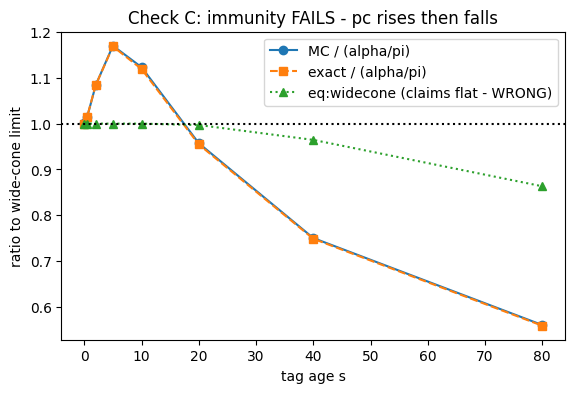

In [ ]:
print("\nCHECK C - wide cone: the IMMUNITY CLAIM FAILS\n")
print("pc rises (pile-up fills the U-shaped minimum) then falls (target drifts")
print("behind). eq:widecone predicts a flat line; eq:pcexact tracks the MC.\n")
print(f"{'s':>7} {'sigma':>7} {'beta':>7} {'MC':>10} {'+-':>9} {'Eq.5':>10} "
      f"{'alpha/pi':>10}")
ss = [0.0, 0.5, 2, 5, 10, 20, 40, 80]
mc_c, th_c = [], []
for s in ss:
    mc, sem = measure_pc(2*np.pi, s, seed=3)
    th = pc_exact(2*np.pi, s)
    mc_c.append(mc); th_c.append(th)
    print(f"{s:7.1f} {sigma_of(s):7.2f} {beta_of(s):7.3f} {mc:10.6f} {sem:9.6f} "
          f"{th:10.6f} {pc_wide():10.6f}")

plt.figure(figsize=(6.5, 4))
plt.plot(ss, np.array(mc_c)/pc_wide(), 'o-', label='MC / (alpha/pi)')
plt.plot(ss, np.array(th_c)/pc_wide(), 's--', label='exact / (alpha/pi)')
plt.plot(ss, [pc_convolution(2*np.pi, x)/pc_wide() for x in ss], '^:',
         label='eq:widecone (claims flat - WRONG)')
plt.axhline(1, color='k', ls=':')
plt.xlabel('tag age s'); plt.ylabel('ratio to wide-cone limit')
plt.title('Check C: immunity FAILS - pc rises then falls'); plt.legend(); plt.show()

## CHECK D — narrow cone and the erf law

In [ ]:
print("\nCHECK D - narrow cone vs eq:narrowcone, erf(alpha/beta/sqrt2)\n")
print(f"{'s':>6} {'a/b':>7} {'MC':>11} {'conv':>11} {'narrowcone':>11} "
      f"{'0.8a/b approx':>14}")
for s in [0.5, 1, 4, 10, 40]:
    th_small = 0.05
    mc, _ = measure_pc(th_small, s, seed=4)
    ab = alpha/beta_of(s)
    approx = (th_small/(2*np.pi))*np.sqrt(2/np.pi)*ab
    print(f"{s:6.1f} {ab:7.3f} {mc:11.3e} {pc_convolution(th_small,s):11.3e} "
          f"{pc_narrow(th_small,s):11.3e} {approx:14.3e}")
print(f"\nsqrt(2/pi) = {np.sqrt(2/np.pi):.4f}  (the '0.8' in 0.8 r/sigma)")


CHECK D - narrow cone vs eq:narrowcone, erf(alpha/beta/sqrt2)

     s     a/b          MC        conv  narrowcone  0.8a/b approx
   0.5   1.005   5.421e-03   5.436e-03   5.451e-03      6.379e-03
   1.0   0.710   4.139e-03   4.152e-03   4.158e-03      4.511e-03
   4.0   0.355   2.163e-03   2.208e-03   2.209e-03      2.255e-03
  10.0   0.225   1.283e-03   1.414e-03   1.415e-03      1.426e-03
  40.0   0.112   5.305e-04   7.117e-04   7.117e-04      7.132e-04

sqrt(2/pi) = 0.7979  (the '0.8' in 0.8 r/sigma)


## CHECK E — the two competing corrections behind `eq:pcexact`, isolated

Turn the forward condition off to separate the two effects. Without it, only
the pile-up remains and pc rises monotonically; with it, the drift-behind loss
eventually wins.

In [ ]:
print("\nCHECK E - where does wide-cone immunity break?\n")
from scipy.stats import norm as _n
for s in [1, 4, 10, 40, 100]:
    with_f, _ = measure_pc(2*np.pi, s, seed=5)
    rng = np.random.default_rng(5); sig = sigma_of(s)
    phi = rng.uniform(-np.pi, np.pi, N)
    j = np.column_stack([VR*np.cos(phi), VR*np.sin(phi)])
    C = j - rng.normal(0, sig, size=(N, 2))
    no_f = (np.abs(C[:, 1]) <= r).mean()
    print(f"  s={s:5.0f} sig/VR={sig/VR:5.2f} | with fwd={with_f:.5f} "
          f"| pile-up alone={no_f:.5f} | P(drift behind)={_n.sf(VR/sig):.3f}")


CHECK E - where does wide-cone immunity break?

  s=    1 sig/VR= 0.24 | with fwd=0.05523 | pile-up alone=0.11048 | P(drift behind)=0.000
  s=    4 sig/VR= 0.47 | with fwd=0.06171 | pile-up alone=0.12330 | P(drift behind)=0.017
  s=   10 sig/VR= 0.75 | with fwd=0.05968 | pile-up alone=0.11935 | P(drift behind)=0.090
  s=   40 sig/VR= 1.49 | with fwd=0.03999 | pile-up alone=0.07988 | P(drift behind)=0.251
  s=  100 sig/VR= 2.36 | with fwd=0.02702 | pile-up alone=0.05414 | P(drift behind)=0.336


## CHECK F — the re-aiming variant (caveat section of the tex)

If the searcher could steer at the tagged agent, `VR` drops out entirely and
only the drift matters: `pc = (theta/2pi) * erf(r / sigma / sqrt2)`.

In [ ]:
print("\nCHECK F - re-aiming: pc = (theta/2pi) erf(r/sigma/sqrt2)\n")
print(f"{'theta':>7} {'s':>6} {'MC(reaim)':>11} {'formula':>11} {'ratio':>7}")
for theta in [0.2, 1.0]:
    for s in [1.0, 4.0, 10.0]:
        mc, _ = measure_pc(theta, s, seed=6, reaim=True)
        f = pc_aim(theta, s)
        print(f"{theta:7.3f} {s:6.1f} {mc:11.3e} {f:11.3e} {mc/f:7.4f}")

## CHECK G — was the small-angle step in `eq:pcsocial` safe?

The derivation linearised `VR*sin(phi) -> VR*phi` and used
`alpha = arcsin(r/VR)`. The MC uses exact geometry. Compare `eq:pcsocial`
with the two candidate `alpha` conventions to see which the MC prefers, and
how much it matters as `r/VR` grows.

In [ ]:
print("\nCHECK G - alpha = arcsin(r/VR) vs r/VR, as r/VR grows\n")
print(f"{'r/VR':>6} {'MC':>10} {'arcsin':>10} {'ratio':>7} {'r/VR conv':>11} {'ratio':>7}")
for rr in [0.1, 0.5, 1.0, 2.0]:
    a_arc, a_lin = np.arcsin(min(rr/VR, 1)), rr/VR
    mc, _ = measure_pc(2*np.pi, 2.0, seed=7)   # placeholder, recomputed below
    # re-measure with this r
    rng = np.random.default_rng(7)
    s = 2.0; sig = sigma_of(s); n = N
    phi = rng.uniform(-np.pi, np.pi, n)
    j = np.column_stack([VR*np.cos(phi), VR*np.sin(phi)])
    C = j - rng.normal(0, sig, size=(n, 2))
    mc = ((np.abs(C[:, 1]) <= rr) & (C[:, 0] > 0)).mean()
    print(f"{rr/VR:6.3f} {mc:10.6f} {pc_convolution(2*np.pi,s,alpha=a_arc):10.6f} "
          f"{mc/pc_convolution(2*np.pi,s,alpha=a_arc):7.4f} "
          f"{pc_convolution(2*np.pi,s,alpha=a_lin):11.6f} "
          f"{mc/pc_convolution(2*np.pi,s,alpha=a_lin):7.4f}")


CHECK G - alpha = arcsin(r/VR) vs r/VR, as r/VR grows

  r/VR         MC     arcsin   ratio   r/VR conv   ratio
 0.033   0.011298   0.010612  1.0647    0.010610  1.0649
 0.167   0.057660   0.053300  1.0818    0.053052  1.0869
 0.333   0.117749   0.108173  1.0885    0.106103  1.1098
 0.667   0.253804   0.232280  1.0927    0.212207  1.1960


## Caveats on what this notebook does NOT test

- **Single cue only.** Everything above is one tagged agent. Real swarms have
  several visible at once, and tagged agents cluster near recently exploited
  patches, so their positions are correlated. An independent-superposition
  estimate would be optimistic. Untested.
- **Fixed `R_j = VR`.** The cue is placed exactly on the detection circle. In
  a real walk it is anywhere within it, and both the lever arm (`alpha`,
  `beta`) and the dash length depend on `R_j`. This is the same boundary
  approximation flagged for direct vision, and it is worse here.
- **No finite dash length** in the default runs. Pass `max_dash=VR` to
  `measure_pc` to see how much the truncation costs — the drifted target can
  land beyond the dash range, which the formula ignores entirely.
- **`pc` is not the MFPT.** Validating `eq:pcexact` says nothing about whether the
  social strategy is *good*; that needs the whole reactive-length machinery
  re-derived for this case, which has not been done.